# Notebook 1: Dataset preparation

The workflow to prepare the datasets used in this work are preesented below. 

The final datasets containing the standardized SMILES strings are made available.

## Imports

In [7]:
import chembl_structure_pipeline  # used in standardize.py
import numpy as np
import pandas as pd
import rdkit
from rdkit import Chem
from rdkit.Chem import Descriptors, PandasTools, rdFingerprintGenerator
from standardize import new_standardize_smiles

In [6]:
print("chembl_structure_pipeline version:", chembl_structure_pipeline.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("RDKit version:", rdkit.__version__)

chembl_structure_pipeline version: 1.0.0
NumPy version: 1.22.3
Pandas version: 1.4.2
RDKit version: 2022.03.3


## Functions

In [19]:
# Remove low/high MW
def remove_low_high_mw(df_orig):
    df = df_orig.copy()
    df["MW"] = df['mol'].apply(Descriptors.MolWt)
    df = df[(df["MW"] > 200) & (df["MW"] < 1000)]
    return df

# Create RDKit fingerprint generator object
fp_size = 1024
fp_radius = 3
mfpgen = rdFingerprintGenerator.GetMorganGenerator(radius=fp_radius, fpSize=fp_size)

# Calculate fingerprint with RDKit and convert to list
def fp_as_list(mol):
    fp = list(mfpgen.GetFingerprintAsNumPy(mol))
    return fp

# Standardize SMILES and perform operations on datasets
def standardize_dataset(df_orig):
    df = df_orig.copy()
    print(df.shape)

    # Standardize SMILES
    df["standard_SMILES"] = df["SMILES"].apply(lambda smi: new_standardize_smiles(smi, return_mol=False))
    # Drop failed conversions
    df = df[df["standard_SMILES"].notna()].copy()
    # Add mol column
    PandasTools.AddMoleculeColumnToFrame(df, 'standard_SMILES', 'mol')
    # MW filter
    df = remove_low_high_mw(df)
    # Drop duplicates (same standardized SMILES)
    df = df.drop_duplicates(subset="standard_SMILES").copy()
    # Add column with fingerprint as list
    df["fp"] = df["mol"].apply(fp_as_list)
    # Drop unused columns
    df.drop(["SMILES", "mol", "MW"], axis=1, inplace=True)
    print(df.shape)

    return df

## Create dataset of cruzain inhibitors

`cz_26`: Cruzain inhibition data imported from ChEMBL (version 26, March 2020)

`neq`: Cruzain inhibition data from in-house database

In [5]:
cz_26 = pd.read_csv("cruzain_chembl26.csv", sep=';')

In [6]:
neq = pd.read_csv("neq_standardized_update_chembl.csv", sep=';')

In [7]:
cz_26.columns

Index(['assay_chembl_id', 'target_type', 'tax_id', 'canonical_smiles',
       'molecule_chembl_id', 'standard_type', 'pchembl_value'],
      dtype='object')

In [8]:
df_to_merge = cz_26[cz_26['standard_type'].isin(["Ki", "IC50"])].copy()
df_to_merge = df_to_merge[['canonical_smiles', 'pchembl_value']].copy()
df_to_merge = df_to_merge.dropna()
df_to_merge.shape

(623, 2)

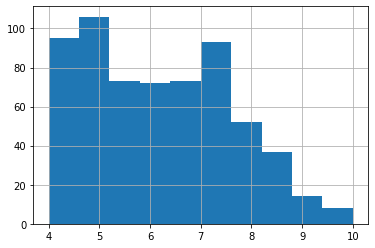

In [9]:
df_to_merge["pchembl_value"].hist();

In [10]:
# Add Nequimed compounds
neq_to_merge = neq[["standard_SMILES", "pKi"]]
neq_to_merge.columns = ['canonical_smiles', 'pchembl_value']
neq_to_merge = neq_to_merge.iloc[:150]
neq_to_merge.shape

(150, 2)

In [11]:
df = pd.concat([df_to_merge, neq_to_merge])
df.shape

(773, 2)

In [12]:
df.columns = ["SMILES", "pchembl_value"]

In [13]:
%%capture
df_std = standardize_dataset(df)

In [14]:
df_std.shape

(607, 3)

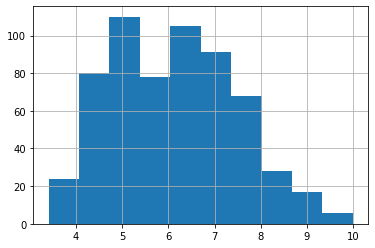

In [15]:
df_std["pchembl_value"].hist();

In [23]:
# Export dataset
df_std.to_csv('cruzain_26_neq_fps.csv', sep=";", index=False)

# DrugBank

In [ ]:
sdf_file_path = 'drugbank_approved_structures_17-03-2022.sdf'

# Read the SDF file
sdf_supplier = Chem.SDMolSupplier(sdf_file_path)

# Initialize lists to store information
smiles_list = []
names_list = []

# Iterate through molecules in the SDF file
for mol in sdf_supplier:
    if mol is not None:
        # Get SMILES
        smiles = Chem.MolToSmiles(mol)
        smiles_list.append(smiles)

        # Get name (you might need to adapt this based on the specific property name in your SDF)
        name = mol.GetProp('GENERIC_NAME')  # '_Name' is a common property for names in SDF files
        # name = mol.GetProp('_Name')
        names_list.append(name)

# Create a DataFrame
data = {'Name': names_list, 'SMILES': smiles_list}
drugbank = pd.DataFrame(data)


In [20]:
drugbank.shape

(2567, 2)

In [21]:
drugbank.columns = ["Name", "SMILES"]
drugbank.head()

,Name,SMILES
0,Bivalirudin,CC[C@H](C)[C@H](NC(=O)[C@H](CCC(=O)O)NC(=O)[C@...
1,Leuprolide,CCNC(=O)[C@@H]1CCCN1C(=O)[C@H](CCCNC(=N)N)NC(=...
2,Goserelin,CC(C)C[C@H](NC(=O)[C@@H](COC(C)(C)C)NC(=O)[C@H...
3,Gramicidin D,CC(C)C[C@@H](NC(=O)CNC(=O)[C@@H](NC=O)C(C)C)C(...
4,Desmopressin,N=C(N)NCCC[C@@H](NC(=O)[C@@H]1CCCN1C(=O)[C@@H]...


In [ ]:
%%capture
drugbank_std = standardize_dataset(drugbank)

In [45]:
drugbank_std.head()

,Name,standard_SMILES,fp
11,Pyridoxal phosphate,Cc1ncc(COP(=O)(O)O)c(C=O)c1O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
13,Ademetionine,C[S+](CCC(N)C(=O)[O-])CC1OC(n2cnc3c(N)ncnc32)C...,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
16,Biotin,O=C(O)CCCCC1SCC2NC(=O)NC21,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."
23,Adenosine phosphate,Nc1ncnc2c1ncn2C1OC(COP(=O)(O)O)C(O)C1O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
24,alpha-Linolenic acid,CCC=CCC=CCC=CCCCCCCCC(=O)O,"[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..."


In [47]:
drugbank_std.shape

(1883, 3)

In [46]:
# Export DataFrame
drugbank_std.to_csv("drugbank_fps.csv", sep=";", index=False)

## Antivirals

antiviral_updated.sdf is the file available in [Kaggle](https://www.kaggle.com/datasets/rishidamarla/testable-antiviral-drugs-for-covid19), originally released by [CAS](https://www.cas.org/covid-19-antiviral-compounds-dataset).


In [11]:
sdf_file_path = '../CAS_antivirals/antiviral_updated.sdf'

# Read the SDF file
sdf_supplier = Chem.SDMolSupplier(sdf_file_path)

# Initialize lists to store information
smiles_list = []
names_list = []

# Iterate through molecules in the SDF file
for mol in sdf_supplier:
    if mol is not None:
        # Get SMILES
        smiles = Chem.MolToSmiles(mol)
        smiles_list.append(smiles)

        # Get name
        name = mol.GetProp('_Name')
        names_list.append(name)

# Create a DataFrame
data = {'Name': names_list, 'SMILES': smiles_list}
av = pd.DataFrame(data)


[12:03:49] WARNING: not removing hydrogen atom without neighbors
[12:03:49] Explicit valence for atom # 14 N, 4, is greater than permitted
[12:03:49] ERROR: Could not sanitize molecule ending on line 6069
[12:03:49] ERROR: Explicit valence for atom # 14 N, 4, is greater than permitted
[12:03:50] WARNING: not removing hydrogen atom without neighbors
[12:03:50] Explicit valence for atom # 17 O, 3, is greater than permitted
[12:03:50] ERROR: Could not sanitize molecule ending on line 45500
[12:03:50] ERROR: Explicit valence for atom # 17 O, 3, is greater than permitted
[12:03:50] Explicit valence for atom # 0 Ba, 5, is greater than permitted
[12:03:50] ERROR: Could not sanitize molecule ending on line 89321
[12:03:50] ERROR: Explicit valence for atom # 0 Ba, 5, is greater than permitted
[12:03:51] Explicit valence for atom # 2 N, 4, is greater than permitted
[12:03:51] ERROR: Could not sanitize molecule ending on line 165660
[12:03:51] ERROR: Explicit valence for atom # 2 N, 4, is greater

In [12]:
# Export DataFrame
av.to_csv("antiviral_updated.csv", sep=";", index=False)

# Generate FPs for antivirals

In [14]:
antivirals = pd.read_csv("antiviral_updated.csv", sep=';', header=0)
antivirals.head()

,Name,SMILES
0,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCCC3=O)cc(Cl)c1F)c(=O)c(C...
1,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCCC3)cc(Cl)c1F)c(=O)c(C(=...
2,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCOC3=O)cc(Cl)c1F)c(=O)c(C...
3,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCOCC3)cc(Cl)c1F)c(=O)c(C(...
4,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCCCC3)cc(Cl)c1F)c(=O)c(C(...


In [5]:
antivirals = pd.read_csv("antiviral_updated.txt", sep='\t', header=None)

In [15]:
antivirals.shape

(48876, 2)

In [16]:
# Split DataFrame into 10 parts
split_dfs = np.array_split(antivirals, 10)

In [17]:
processed_dfs = [pd.DataFrame()]*10

In [20]:
%%capture
for i in range(9):
    processed_dfs[i] = standardize_dataset(split_dfs[i])

In [27]:
# Merge all DataFrames and drop duplicates
antivirals_std = pd.concat(processed_dfs)
antivirals_std.shape  # old

(35791, 3)

In [21]:
# Merge all DataFrames and drop duplicates
antivirals_std = pd.concat(processed_dfs)
antivirals_std.shape

(35777, 3)

In [22]:
antivirals_std.head()

,Name,standard_SMILES,fp
0,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCCC3=O)cc(Cl)c1F)c(=O)c(C...,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
1,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCCC3)cc(Cl)c1F)c(=O)c(C(=...,"[0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
2,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCOC3=O)cc(Cl)c1F)c(=O)c(C...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
3,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCOCC3)cc(Cl)c1F)c(=O)c(C(...,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."
4,"3-Quinolinecarboxylic acid, 6-[[3-chloro-2-flu...",COc1cc2c(cc1Cc1cc(N3CCCCC3)cc(Cl)c1F)c(=O)c(C(...,"[0, 1, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, ..."


In [5]:
antivirals_std.drop_duplicates(subset="standard_SMILES", inplace=True)
antivirals_std.shape  # old

(33197, 3)

In [23]:
antivirals_std.drop_duplicates(subset="standard_SMILES", inplace=True)
antivirals_std.shape

(33211, 3)

In [ ]:
# Export processed DataFrame
antivirals_std.to_csv("antivirals_std.csv", sep=";", index=False)  # old

In [24]:
# Export processed DataFrame
antivirals_std.to_csv("antivirals_std_rdkit.csv", sep=";", index=False)